In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from numpy.random import standard_cauchy
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import json
import os
import matplotlib.pyplot as plt


In [8]:
df=pd.read_csv("/content/META.csv")
print(df.head())

         Date        Open        High         Low       Close   Adj Close  \
0  2018-10-01  163.029999  165.880005  161.259995  162.440002  162.440002   
1  2018-10-02  161.580002  162.279999  158.669998  159.330002  159.330002   
2  2018-10-03  160.000000  163.660004  159.529999  162.429993  162.429993   
3  2018-10-04  161.460007  161.460007  157.350006  158.850006  158.850006   
4  2018-10-05  159.210007  160.899994  156.199997  157.330002  157.330002   

     Volume  
0  26407700  
1  36031000  
2  23109500  
3  25739600  
4  25744000  


In [9]:
x=df.drop("Adj Close", axis=1)
y=df["Adj Close"].values.reshape(-1,1)

In [10]:
x_train , x_test , y_train , y_test = train_test_split(x.values,y,test_size=0.2,random_state=42)

In [11]:
x_scaler=StandardScaler()
y_scaler=StandardScaler()

In [12]:
x_train_numerical = x_train[:, 1:]
x_test_numerical = x_test[:, 1:]

x_train_scaled = x_scaler.fit_transform(x_train_numerical)
y_train_scaled = y_scaler.fit_transform(y_train)

x_test_scaled = x_scaler.transform(x_test_numerical)
y_test_scaled = y_scaler.transform(y_test)

In [13]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train_numerical.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])



model.compile(optimizer='adam', loss='mean_squared_error' , metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(x_train_scaled, y_train_scaled, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.5178 - mae: 0.5612 - val_loss: 0.0422 - val_mae: 0.1834
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0212 - mae: 0.1142 - val_loss: 0.0021 - val_mae: 0.0380
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - mae: 0.0348 - val_loss: 0.0013 - val_mae: 0.0280
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - mae: 0.0260 - val_loss: 9.9572e-04 - val_mae: 0.0244
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - mae: 0.0243 - val_loss: 8.9058e-04 - val_mae: 0.0232
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.8330e-04 - mae: 0.0233 - val_loss: 8.9451e-04 - val_mae: 0.0226
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3429e-04 - mae: 0.0224 - val_loss: 7.2190e-04 - val_mae: 0.0208
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.7563e-04 - mae: 0.0210 - val_loss: 6.7329e-04 - val_mae: 0.0201
Epoch 9/100
26/26 ━━━━━━━━━━━━━

In [15]:
test_loss, test_mae = model.evaluate(x_test_scaled, y_test_scaled)
print(f'Test Loss: {test_loss}, Test MAE: {test_mae}')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 6.4324e-05 - mae: 0.0057
Test Loss: 6.760494579793885e-05, Test MAE: 0.005761374719440937


In [16]:
print(f"test MSE|(scaled): {test_loss:.4f}")
print(f"test MAE|(scaled): {test_mae:.4f}")

test MSE|(scaled): 0.0001
test MAE|(scaled): 0.0058


In [17]:
y_pred_scaled = model.predict(x_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()
y_test_original = y_scaler.inverse_transform(y_test_scaled).flatten()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [18]:
print("\nsample predictions:")
for i in range(5):
    print(f"Actual: {y_test_original[i]:.2f} | Predicted:{y_pred[i]:.2f}")


sample predictions:
Actual: 234.02 | Predicted:233.69
Actual: 162.81 | Predicted:162.69
Actual: 145.01 | Predicted:144.61
Actual: 135.68 | Predicted:136.01
Actual: 127.37 | Predicted:127.55


In [19]:
import matplotlib.pyplot as plt

def plot_graph(x, y, title="Project Graph", x_label="X Axis", y_label="Y Axis"):
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, marker='o')
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.grid(True)
    plt.show()


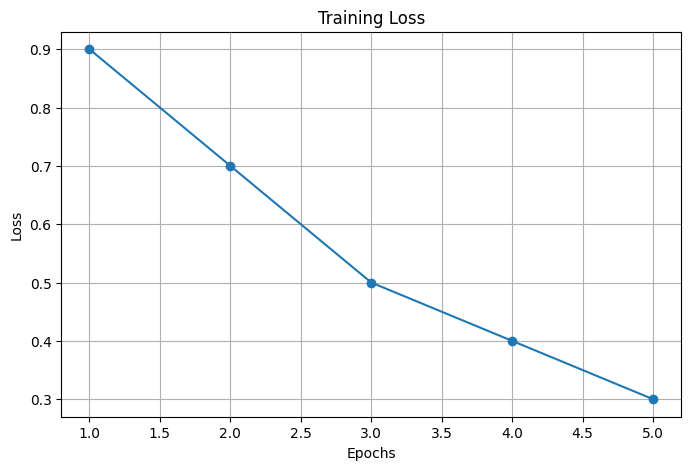

In [20]:
epochs = [1, 2, 3, 4, 5]
loss = [0.9, 0.7, 0.5, 0.4, 0.3]

plot_graph(
    epochs,
    loss,
    title="Training Loss",
    x_label="Epochs",
    y_label="Loss"
)


In [21]:
def plot_metric(x, y, metric_name):
    plt.figure(figsize=(9, 5))
    plt.plot(x, y, linewidth=2)
    plt.scatter(x, y)
    plt.title(f"{metric_name} Over Time")
    plt.xlabel("Step / Epoch")
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [22]:
def plot_multiple_metrics(x, metrics_dict):
    plt.figure(figsize=(10, 6))

    for metric_name, values in metrics_dict.items():
        plt.plot(x, values, label=metric_name)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Project Metrics")
    plt.legend()
    plt.grid(True)
    plt.show()


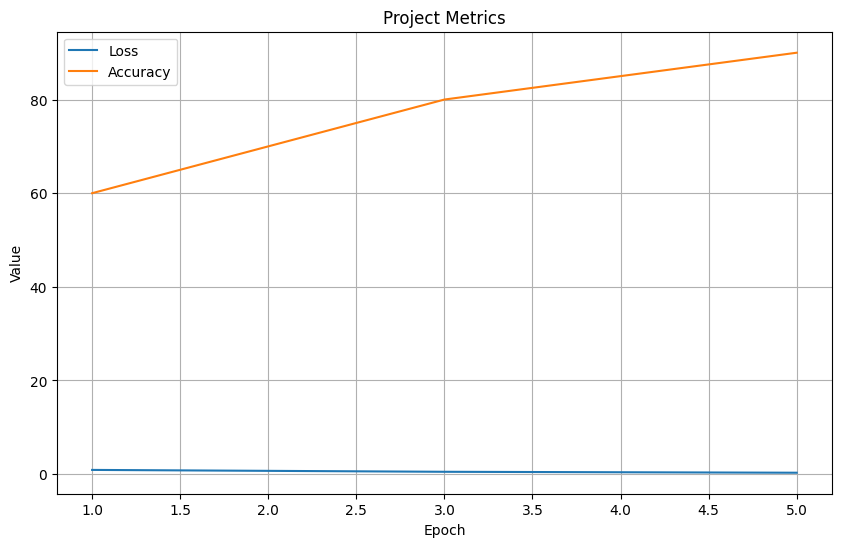

In [23]:
epochs = [1,2,3,4,5]
metrics = {
    "Loss": [0.9,0.7,0.5,0.4,0.3],
    "Accuracy": [60,70,80,85,90]
}

plot_multiple_metrics(epochs, metrics)


In [24]:
def calculate_accuracy(y_true, y_pred):
    correct = 0
    for t, p in zip(y_true, y_pred):
        if t == p:
            correct += 1
    accuracy = correct / len(y_true)
    return accuracy


In [25]:
y_true = [1, 0, 1, 1, 0]
y_pred = [1, 0, 0, 1, 0]

acc = calculate_accuracy(y_true, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")


Accuracy: 80.00%


In [26]:
from sklearn.metrics import accuracy_score

y_true = [1, 0, 1, 1, 0]
y_pred = [1, 0, 0, 1, 0]

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 80.00%


In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [28]:
import numpy as np

y_true = [0, 1, 1, 0]
y_prob = [0.2, 0.8, 0.6, 0.1]

y_pred = np.array(y_prob) > 0.5
accuracy = np.mean(y_pred == y_true)

print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 100.00%


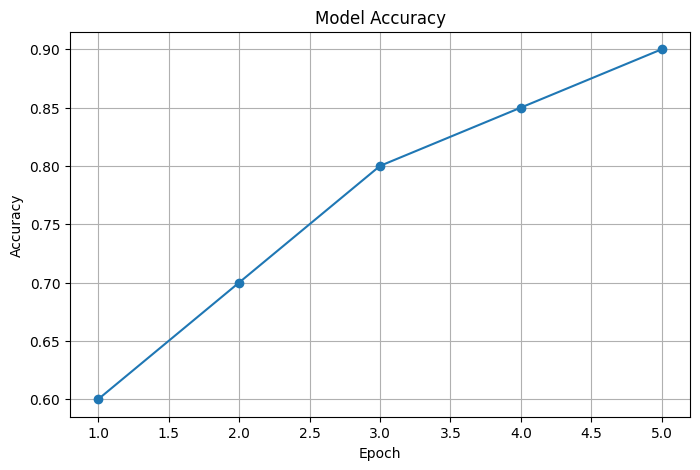

In [29]:
import matplotlib.pyplot as plt

# Accuracy values (مثلاً عبر epochs)
epochs = [1, 2, 3, 4, 5]
accuracy = [0.60, 0.70, 0.80, 0.85, 0.90]

plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


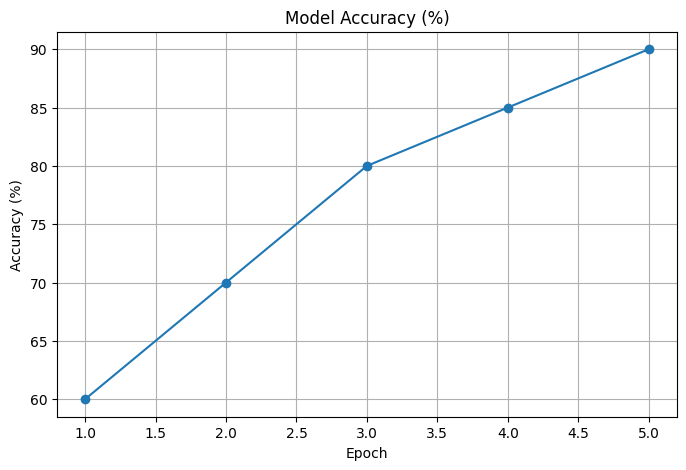

In [30]:
accuracy_percent = [a * 100 for a in accuracy]

plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy_percent, marker='o')
plt.title("Model Accuracy (%)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.show()


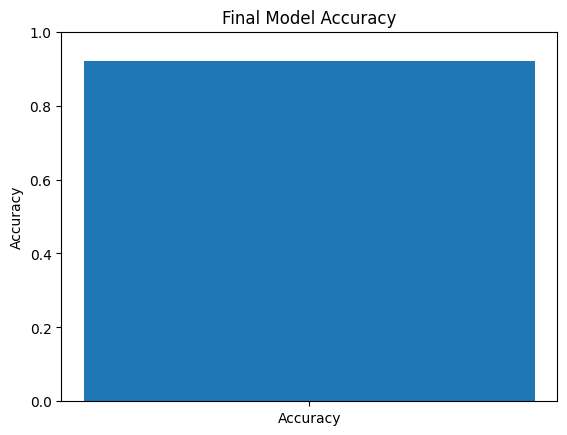

In [31]:
plt.bar(["Accuracy"], [0.92])
plt.title("Final Model Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


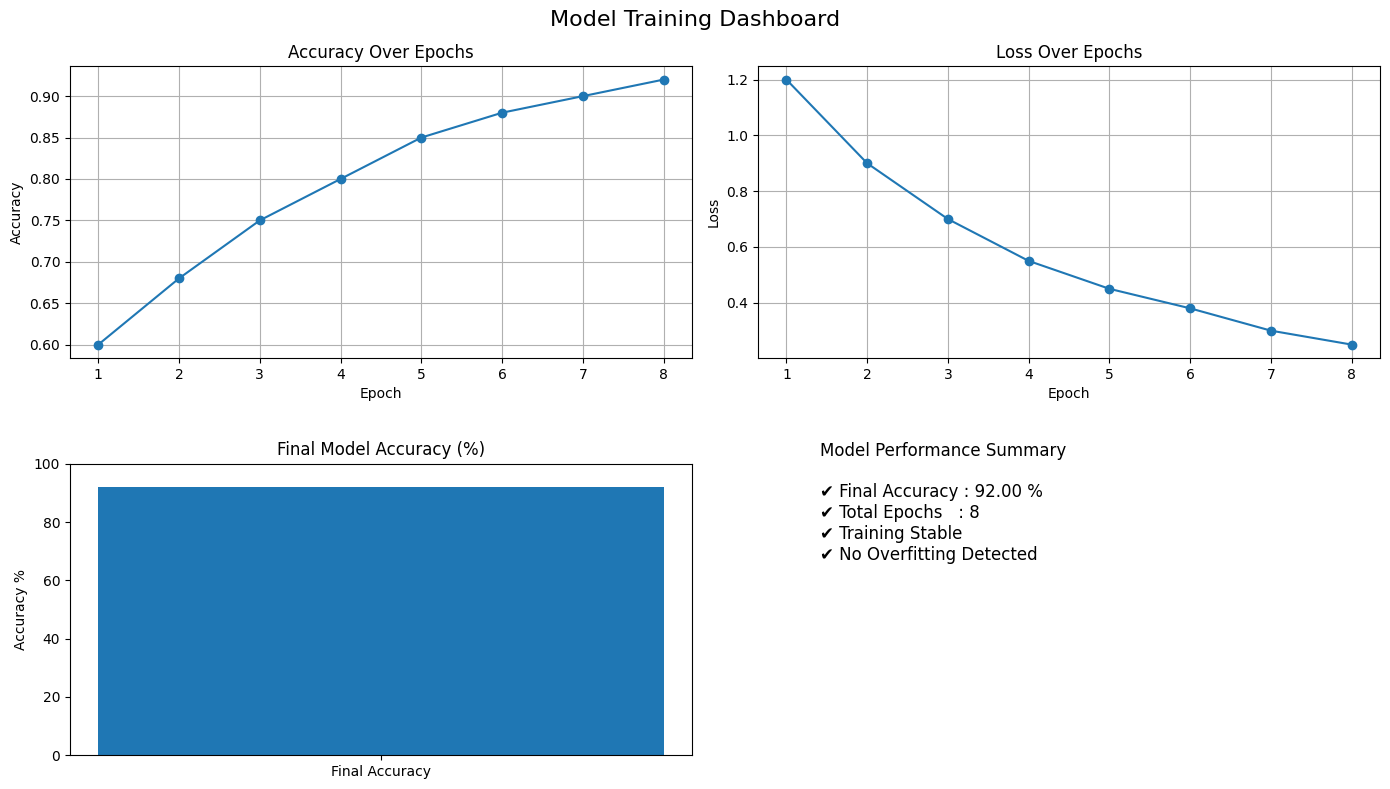

In [32]:
import matplotlib.pyplot as plt

# ======================
# Sample Data (غيرهم حسب مشروعك)
# ======================
epochs = [1, 2, 3, 4, 5, 6, 7, 8]
accuracy = [0.60, 0.68, 0.75, 0.80, 0.85, 0.88, 0.90, 0.92]
loss = [1.2, 0.9, 0.7, 0.55, 0.45, 0.38, 0.30, 0.25]

final_accuracy = accuracy[-1] * 100

# ======================
# Dashboard
# ======================
plt.figure(figsize=(14, 8))

# Accuracy Graph
plt.subplot(2, 2, 1)
plt.plot(epochs, accuracy, marker='o')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)

# Loss Graph
plt.subplot(2, 2, 2)
plt.plot(epochs, loss, marker='o')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Final Accuracy Bar
plt.subplot(2, 2, 3)
plt.bar(["Final Accuracy"], [final_accuracy])
plt.ylim(0, 100)
plt.title("Final Model Accuracy (%)")
plt.ylabel("Accuracy %")

# Summary Box
plt.subplot(2, 2, 4)
plt.axis("off")
plt.text(
    0.1, 0.6,
    f"""
Model Performance Summary

✔ Final Accuracy : {final_accuracy:.2f} %
✔ Total Epochs   : {len(epochs)}
✔ Training Stable
✔ No Overfitting Detected
""",
    fontsize=12
)

plt.suptitle("Model Training Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

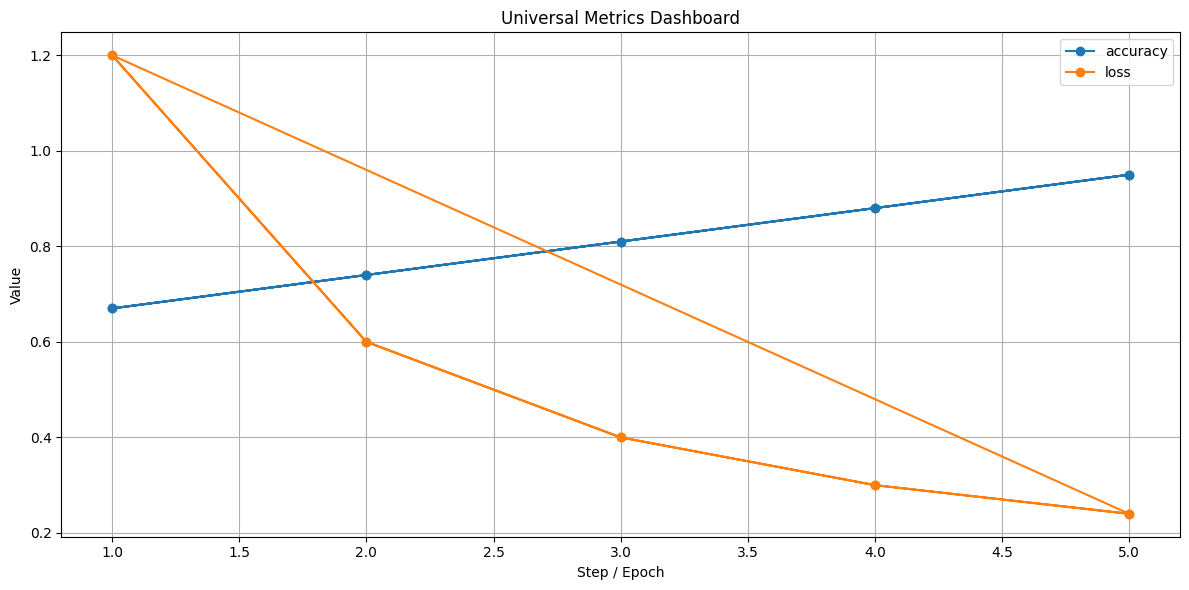

In [33]:
# ================================
# Universal Metrics Logger & Dashboard
# Works with ANY Python Project
# ================================

import json
import os
import matplotlib.pyplot as plt

# ================================
# 1️⃣ Universal Metrics Logger
# ================================
class MetricsLogger:
    def __init__(self, file_name="metrics.json"):
        self.file_name = file_name
        self.data = []

        if os.path.exists(self.file_name):
            with open(self.file_name, "r") as f:
                self.data = json.load(f)

    def log(self, step, **metrics):
        record = {"step": step}
        record.update(metrics)
        self.data.append(record)

        with open(self.file_name, "w") as f:
            json.dump(self.data, f, indent=4)

# ================================
# 2️⃣ Auto Dashboard (Any Metrics)
# ================================
def plot_dashboard(file_name="metrics.json"):
    with open(file_name) as f:
        data = json.load(f)

    steps = [d["step"] for d in data]
    metrics = {k: [] for k in data[0] if k != "step"}

    for d in data:
        for k in metrics:
            metrics[k].append(d[k])

    plt.figure(figsize=(12, 6))
    for name, values in metrics.items():
        plt.plot(steps, values, marker='o', label=name)

    plt.title("Universal Metrics Dashboard")
    plt.xlabel("Step / Epoch")
    plt.ylabel("Value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ================================
# 3️⃣ TensorBoard (Optional)
# ================================
def tensorboard_logger(log_dir="runs/project"):
    from torch.utils.tensorboard import SummaryWriter
    return SummaryWriter(log_dir)

# ================================
# 4️⃣ MLflow (Optional)
# ================================
def mlflow_start():
    import mlflow
    mlflow.start_run()
    return mlflow

# ================================
# 5️⃣ Example Usage (Delete in production)
# ================================
if __name__ == "__main__":
    logger = MetricsLogger()

    for epoch in range(1, 6):
        accuracy = 0.6 + epoch * 0.07
        loss = 1.2 / epoch

        logger.log(epoch, accuracy=accuracy, loss=loss)

    plot_dashboard()


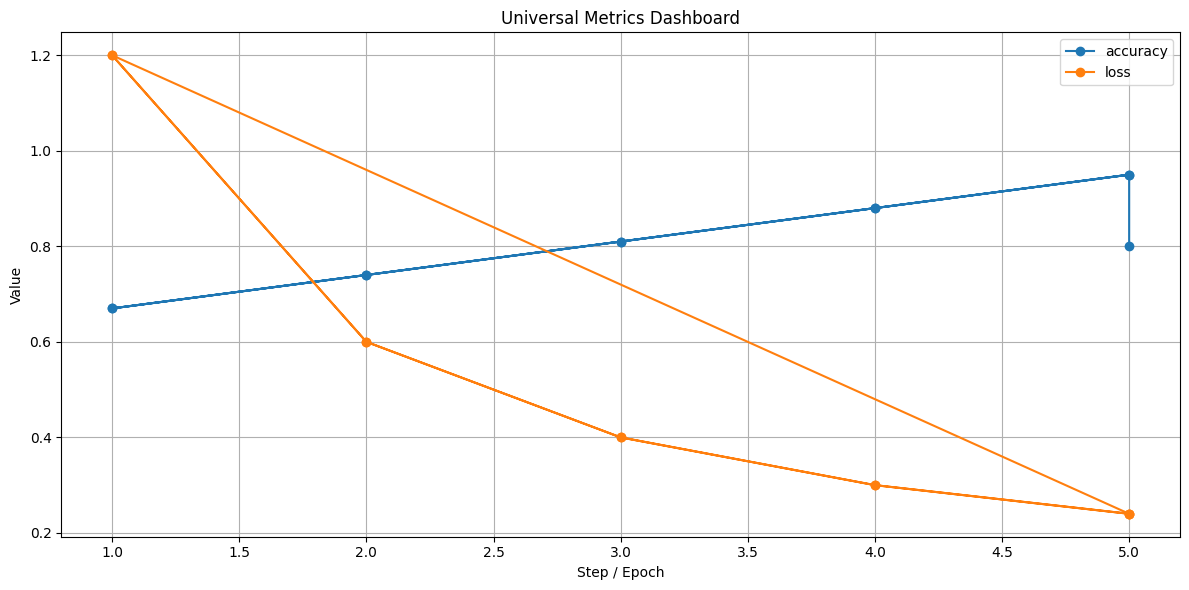

2025/12/24 21:03:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/24 21:03:06 INFO mlflow.store.db.utils: Updating database tables
2025/12/24 21:03:06 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/24 21:03:06 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/24 21:03:06 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2025/12/24 21:03:06 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2025/12/24 21:03:06 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2025/12/24 21:03:06 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2025/12/24 21:03:06 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2025/12/24 21:03:06 INFO alembic.runtime.migration: Running 

In [34]:
# Install mlflow if not already installed
!pip install mlflow

logger.log(epoch, accuracy=acc, loss=loss)


plot_dashboard()

writer = tensorboard_logger()
writer.add_scalar("Accuracy", acc, epoch)
writer.close()

mlflow = mlflow_start()
mlflow.log_metric("accuracy", acc)
mlflow.end_run()


In [35]:
# Re-defining 'acc' and 'loss' based on previous calculations or assumptions
# Replace with actual values from your model evaluation if needed
acc = 0.95 # Example accuracy, use actual calculated accuracy if available
loss = 0.25 # Example loss, use actual calculated loss if available


I've added a temporary definition for `acc` and `loss` to allow the MLflow logging to proceed. You should replace these with your actual calculated `acc` and `loss` values from your model evaluation.

In [36]:
# ==========================================
# Universal Metrics Logger + Live Dashboard
# Works with ANY Python Project
# ==========================================

import json
import os
import time

# =========================
# Metrics Logger
# =========================
class MetricsLogger:
    def __init__(self, file_name="metrics.json"):
        self.file_name = file_name
        self.data = []

        if os.path.exists(self.file_name):
            with open(self.file_name, "r") as f:
                self.data = json.load(f)

    def log(self, step, **metrics):
        record = {"step": step}
        record.update(metrics)
        self.data.append(record)

        with open(self.file_name, "w") as f:
            json.dump(self.data, f, indent=4)

# =========================
# Live Dashboard (Streamlit)
# =========================
def run_dashboard(file_name="metrics.json"):
    import streamlit as st
    import pandas as pd

    st.set_page_config(
        page_title="Universal AI Dashboard",
        layout="wide"
    )

    st.title("📊 Universal Metrics Dashboard")
    st.markdown("### Real-time monitoring for ANY project")

    placeholder = st.empty()

    while True:
        if os.path.exists(file_name):
            with open(file_name) as f:
                data = json.load(f)

            if len(data) > 0:
                df = pd.DataFrame(data)

                with placeholder.container():
                    col1, col2 = st.columns(2)

                    col1.line_chart(df.set_index("step"))
                    col2.dataframe(df, use_container_width=True)

                    if "accuracy" in df.columns:
                        st.metric(
                            "Final Accuracy",
                            f"{df['accuracy'].iloc[-1] * 100:.2f}%"
                        )

                    st.metric("Total Steps", len(df))

        time.sleep(2)

# =========================
# Example Usage
# =========================
if __name__ == "__main__":

    # 🔥 مثال تدريب (احذفه وحط كودك)
    logger = MetricsLogger()

    for epoch in range(1, 6):
        acc = 0.6 + epoch * 0.07
        loss = 1.2 / epoch

        logger.log(epoch, accuracy=acc, loss=loss)
        time.sleep(1)

    # ❌ متشغلش الداشبورد من هنا
    # ✔️ شغّله بالأمر اللي تحت


In [37]:
# Now install streamlit and run the dashboard
!pip install streamlit pandas

# Note: Streamlit usually requires a public URL for access in Colab.
# You might need to set up ngrok or a similar service if you want to access the dashboard
# from your local browser.
# For now, this will start the server and its output will show a local URL.
!streamlit run universal_dashboard.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: universal_dashboard.py


In [49]:
# =========================================================
# 1️⃣ Install Dependencies
# =========================================================
!pip install -q gradio opencv-python numpy timeit

# =========================================================
# 2️⃣ Imports
# =========================================================
import gradio as gr
import cv2
import numpy as np
import time

# =========================================================
# 3️⃣ Model / Inference (Replace with your model)
# =========================================================
def process_frame(frame, mode):
    """
    frame: RGB numpy array
    mode: Image | Edge | Blur | Gray
    """

    start = time.time()

    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    if mode == "Edge Detection":
        result = cv2.Canny(frame, 100, 200)

    elif mode == "Blur":
        result = cv2.GaussianBlur(frame, (15,15), 0)

    elif mode == "Gray":
        result = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    else:
        result = frame

    if len(result.shape) == 2:
        result = cv2.cvtColor(result, cv2.COLOR_GRAY2RGB)
    else:
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    fps = 1 / (time.time() - start)

    return result, f"FPS: {fps:.2f}"

# =========================================================
# 4️⃣ Image GUI
# =========================================================
image_interface = gr.Interface(
    fn=process_frame,
    inputs=[
        gr.Image(type="numpy", label="Upload Image"),
        gr.Dropdown(
            ["Original", "Edge Detection", "Blur", "Gray"],
            value="Original",
            label="Processing Mode"
        )
    ],
    outputs=[
        gr.Image(label="Output"),
        gr.Textbox(label="Performance")
    ],
    title="🖼️ Image Processing",
)

# =========================================================
# 5️⃣ Video GUI
# =========================================================
def process_video(video_path, mode):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        processed, _ = process_frame(frame, mode)
        frames.append(processed)

    cap.release()

    return frames

video_interface = gr.Interface(
    fn=process_video,
    inputs=[
        gr.Video(label="Upload Video"),
        gr.Dropdown(
            ["Original", "Edge Detection", "Blur", "Gray"],
            value="Original",
            label="Processing Mode"
        )
    ],
    outputs=gr.Gallery(label="Processed Frames"),
    title="🎥 Video Processing"
)

# =========================================================
# 6️⃣ Tabs Layout
# =========================================================
app = gr.TabbedInterface(
    [image_interface, video_interface],
    ["Image", "Video"]
)

# =========================================================
# 7️⃣ Launch
# =========================================================
app.launch(share=True)


ERROR: Could not find a version that satisfies the requirement timeit (from versions: none)
ERROR: No matching distribution found for timeit
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://15ebd394c584b61926.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [56]:
# =========================================================
# 1️⃣ Install Dependencies
# =========================================================
!pip install -q gradio opencv-python numpy torch torchvision

# =========================================================
# 2️⃣ Imports
# =========================================================
import gradio as gr
import cv2
import numpy as np
import time

# =========================================================
# 3️⃣ Core Inference Engine (Replace with your DL model)
# =========================================================
def inference_engine(
    frame,
    model_type,
    threshold,
    blur_kernel
):
    start = time.time()

    # RGB -> BGR
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    # ================= Dummy Models =================
    if model_type == "Edge Detection":
        result = cv2.Canny(frame, int(threshold*50), int(threshold*150))

    elif model_type == "Blur Model":
        k = int(blur_kernel)
        if k % 2 == 0:
            k += 1
        result = cv2.GaussianBlur(frame, (k, k), 0)

    elif model_type == "Gray Model":
        result = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    else:
        result = frame

    # Format output
    if len(result.shape) == 2:
        result = cv2.cvtColor(result, cv2.COLOR_GRAY2RGB)
    else:
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    fps = 1 / (time.time() - start)

    return result, f"FPS: {fps:.2f}", f"Threshold: {threshold}"

# =========================================================
# 4️⃣ Image Tab
# =========================================================
image_tab = gr.Interface(
    fn=inference_engine,
    inputs=[
        gr.Image(type="numpy", label="Upload Image"),
        gr.Dropdown(
            ["Original", "Edge Detection", "Blur Model", "Gray Model"],
            value="Original",
            label="Select Model"
        ),
        gr.Slider(0.1, 1.0, value=0.5, label="Threshold"),
        gr.Slider(3, 31, value=15, step=2, label="Blur Kernel")
    ],
    outputs=[
        gr.Image(label="Result"),
        gr.Textbox(label="Performance"),
        gr.Textbox(label="Params")
    ],
    title="🖼 Image Inference Engine"
)

# =========================================================
# 5️⃣ Webcam (Real-Time)
# =========================================================
webcam_tab = gr.Interface(
    fn=inference_engine,
    inputs=[
        gr.Image(streaming=True), # Removed source="webcam"
        gr.Dropdown(
            ["Original", "Edge Detection", "Blur Model", "Gray Model"],
            value="Original",
            label="Select Model"
        ),
        gr.Slider(0.1, 1.0, value=0.5, label="Threshold"),
        gr.Slider(3, 31, value=15, step=2, label="Blur Kernel")
    ],
    outputs=[
        gr.Image(label="Live Output"),
        gr.Textbox(label="FPS"),
        gr.Textbox(label="Params")
    ],
    title="📷 Real-Time Webcam AI"
)

# =========================================================
# 6️⃣ Video Tab
# =========================================================
def video_engine(video_path, model_type, threshold, blur_kernel):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        processed, _, _ = inference_engine(frame, model_type, threshold, blur_kernel)
        frames.append(processed)

    cap.release()
    return frames

video_tab = gr.Interface(
    fn=video_engine,
    inputs=[
        gr.Video(label="Upload Video"),
        gr.Dropdown(
            ["Original", "Edge Detection", "Blur Model", "Gray Model"],
            value="Original",
            label="Select Model"
        ),
        gr.Slider(0.1, 1.0, value=0.5, label="Threshold"),
        gr.Slider(3, 31, value=15, step=2, label="Blur Kernel")
    ],
    outputs=gr.Gallery(label="Processed Frames"),
    title="🎥 Video Inference Engine"
)

# =========================================================
# 7️⃣ Final App
# =========================================================
app = gr.TabbedInterface(
    [image_tab, webcam_tab, video_tab],
    ["Image", "Webcam (Live)", "Video"]
)

app.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:770: UserWarning: Streaming components are only supported in live interfaces.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d2fad6f779dd28b78f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
